# Fourier_RRLyrae.pynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack
#from astroML.datasets import fetch_rrlyrae_templates

In [2]:
#templates = fetch_rrlyrae_templates()

Note the textbook Fig. 10.1 uses ${\tt np.fft.fft}$ rather than ${\tt scipy.fftpack}$.

In [3]:
#t, y = templates['115r'].T
#np.savetxt('RRl.data',np.vstack((t,y)).T)
t, y = np.loadtxt('RRl.data',unpack=True)

In [4]:
plt.rcParams.update({'font.size': 21})

Text(0.5, 1.0, 'RR Lyrae light curve')

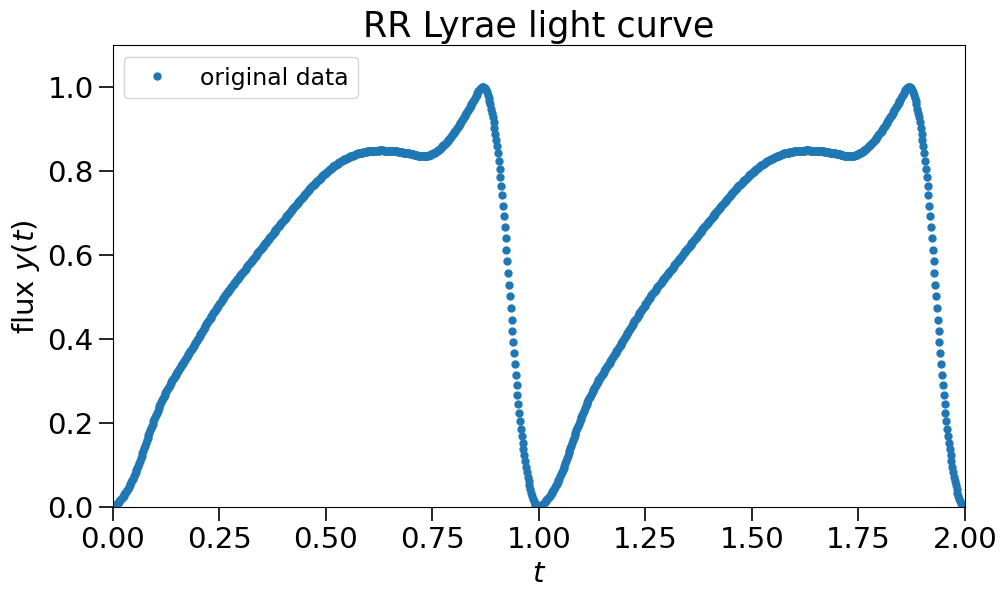

In [5]:
fig1 = plt.figure(figsize=(11,6))
plt.plot(np.concatenate((t,t+1)),np.concatenate((y,y)),'o',ms=5,label='original data')
#plt.grid('on')
plt.xlabel('$t$')
plt.ylabel('flux $y(t)$')
plt.xlim(0,2)
plt.ylim(0,1.1)
plt.legend(loc='best',fontsize=17)
plt.tick_params('both', length=10, width=1.2, which='major')
plt.title('RR Lyrae light curve')

In [6]:
T = t[-1] - t[0] # total time interval
dt = t[1] - t[0] # time step
N = len(t) # number of time steps
df = 1 / N / dt
print('T = %.3f, dt = %.3f, N = %d, df = %.3f' % (T,dt,N,df))
# f = df * (np.arange(N) - N/2 ) # see Ivezić Appendix E and Y_fft_shift
f = np.linspace(0,(N-1.0)/(N*dt),N) # frequency vector
print(f)

T = 0.998, dt = 0.002, N = 500, df = 1.000
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181.
 182. 183. 184. 185. 186. 187. 188

In [9]:
k_max = 10 # reconstruct using 10 frequencies, set to 100 to show from plot below why we truncate at ~10
Y_fft = fftpack.fft(y) # compute the Fourier transform
Y_fft[k_max+1 : -k_max] = 0 # zero-out frequencies higher than k_max
#print(Y_fft.real)
#Y_fft_shift = fftpack.fftshift(Y_fft)
P = abs(Y_fft)**2 # power
#P = np.real(np.conj(Y_fft)*Y_fft) # power, alternative calculation

y_fit = fftpack.ifft(Y_fft).real # reconstruct using k_max modes

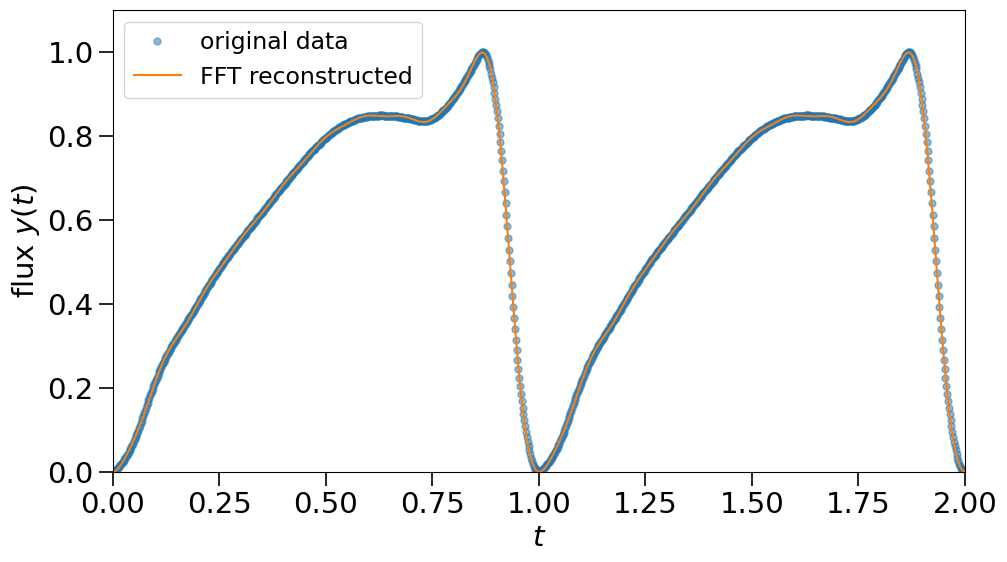

In [10]:
fig2 = plt.figure(figsize=(11,6))
plt.plot(np.concatenate((t,t+1)),np.concatenate((y,y)),'o',ms=5,alpha=0.5,label='original data')
plt.plot(np.concatenate((t,t+1)),np.concatenate((y_fit,y_fit)),'-',label='FFT reconstructed')
#plt.grid('on')
plt.xlabel('$t$')
plt.ylabel('flux $y(t)$')
plt.xlim(0,2)
plt.ylim(0,1.1)
plt.legend(loc='best',fontsize=17)
plt.tick_params('both', length=10, width=1.2, which='major')
#plt.title('RR Lyrae light curve')

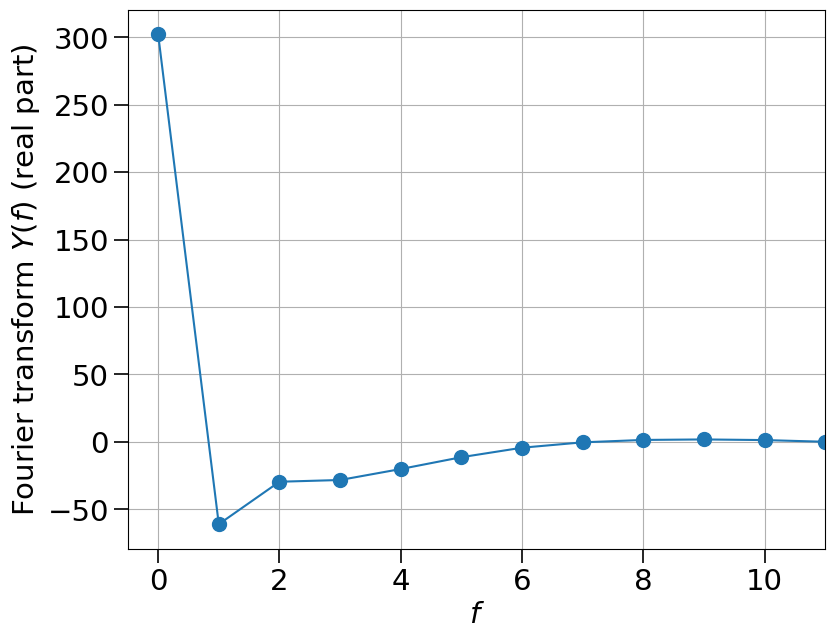

In [11]:
fig3 = plt.figure(figsize=(9,7))
plt.plot(f,Y_fft.real,'o-',ms=10)
plt.grid('on')
plt.xlabel('$f$')
plt.ylabel('Fourier transform $Y(f)$ (real part)')
#plt.xlim(df*(-1-k_max),df*(k_max+1))
plt.xlim(-df/2,df*(k_max+1)) # note there are aliased frequencies near f_max
plt.tick_params('both', length=10, width=1.2, which='major')
#plt.title('RR Lyrae light curve')

/var/folders/vz/7s6xltxx6hzgsp7h3xdc9ss00000gn/T/ipykernel_8712/2881387484.py:8: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-1500,1.1 * np.max(P))


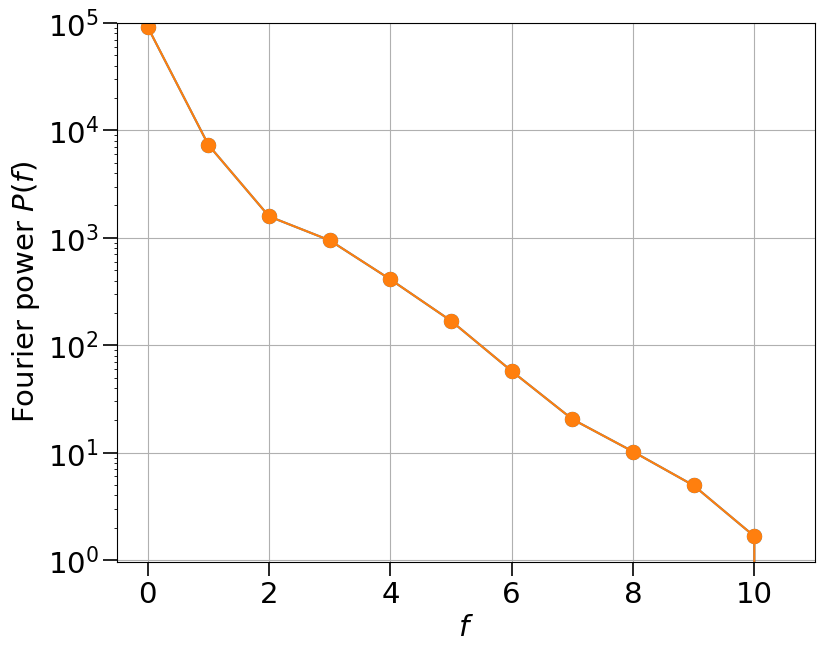

In [12]:
fig4 = plt.figure(figsize=(9,7))
plt.plot(f,P,'o-',ms=10)
plt.semilogy(f,P,'o-',ms=10)
plt.grid('on')
plt.xlabel('$f$')
plt.ylabel('Fourier power $P(f)$')
plt.xlim(-df/2,df*(k_max+1)) # note there are aliased frequencies near f_max
plt.ylim(-1500,1.1 * np.max(P))
plt.tick_params('both', length=10, width=1.2, which='major')
#plt.title('RR Lyrae light curve')

In [ ]:
# A(t) = cos(kx + omega t)